# 2주차: GNN으로 molecular representation 학습하기

이번 주의 질문은 **graph representation을 학습하는 것이 사람이 만든 RDKit descriptor보다 좋은가?**입니다. 1주차와 완전히 같은 seed 42 random split에서 Linear Regression, MLP, GCN, bond-aware GIN을 비교합니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from ai4sci_molecule.week1 import (
    DESCRIPTOR_NAMES, build_baselines, calculate_descriptors,
    load_esol, make_random_split, regression_metrics,
)
from ai4sci_molecule.week2 import (
    ATOM_FEATURE_CARDINALITIES, BOND_FEATURE_CARDINALITIES,
    TrainingConfig, build_gnn_models, predict_gnn, resolve_device, train_gnn,
)

SEED = 42
DEVICE = resolve_device("auto")
CONFIG = TrainingConfig(max_epochs=150, patience=20, seed=SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "UnDotum"
plt.rcParams["axes.unicode_minus"] = False
print(f"학습 device: {DEVICE}")

학습 device: cuda


## 1. 같은 데이터, 같은 split

표현과 모델만 바꾸기 위해 1주차의 902/113/113 index를 그대로 재사용합니다. validation은 early stopping checkpoint 선택에 사용하고, test는 모든 모델 구성을 고정한 뒤 한 번만 평가합니다.

In [2]:
dataset = load_esol(Path("..") / "data" / "MoleculeNet")
split = make_random_split(len(dataset), seed=SEED)
smiles = [graph.smiles for graph in dataset]
targets = np.array([float(graph.y.item()) for graph in dataset])

print(f"분자 수: {len(dataset):,}")
print({name: len(indices) for name, indices in split.items()})
assert [len(split[name]) for name in ("train", "validation", "test")] == [902, 113, 113]

분자 수: 1,128
{'train': 902, 'validation': 113, 'test': 113}


## 2. Atom embedding과 message passing

PyG ESOL graph의 atom은 원자번호, chirality, degree 등 9개 범주형 열입니다. 각 열을 embedding한 뒤 더해 초기 상태 $h_i^{(0)}$를 만듭니다. 세 번의 message passing 후 `global_mean_pool`로 원자 표현의 평균 $h_G$를 만들고 MLP가 logS를 예측합니다.

- **GCN:** 이웃 atom embedding과 graph topology를 aggregate합니다.
- **GIN (GINE):** GIN의 표현력에 bond type, stereo, conjugation embedding $e_{ij}$를 더한 edge-aware 변형입니다.

In [3]:
sample = dataset[0]
feature_summary = pd.DataFrame([
    {"feature": "atom x", "shape": tuple(sample.x.shape), "columns": len(ATOM_FEATURE_CARDINALITIES), "cardinalities": ATOM_FEATURE_CARDINALITIES},
    {"feature": "bond edge_attr", "shape": tuple(sample.edge_attr.shape), "columns": len(BOND_FEATURE_CARDINALITIES), "cardinalities": BOND_FEATURE_CARDINALITIES},
])
display(feature_summary)
print("첫 분자의 atom feature:\n", sample.x[:5])
print("첫 분자의 bond feature:\n", sample.edge_attr[:5])

,feature,shape,columns,cardinalities
0,atom x,"(32, 9)",9,"(119, 9, 11, 12, 9, 5, 8, 2, 2)"
1,bond edge_attr,"(68, 3)",3,"(22, 6, 2)"


첫 분자의 atom feature:
 tensor([[8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1]])
첫 분자의 bond feature:
 tensor([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]])


## 3. Descriptor baseline validation

1주차와 같은 5개 descriptor를 사용합니다. 이번 핵심 비교에 맞춰 Dummy는 제외하고 Linear와 MLP만 가져옵니다. 두 모델 모두 train에서만 fit하며 아직 test는 보지 않습니다.

In [4]:
descriptors = calculate_descriptors(smiles)
X = descriptors[list(DESCRIPTOR_NAMES)].to_numpy(dtype=float)
baseline_models = {
    "Linear Regression": build_baselines(seed=SEED)["Linear"],
    "MLP": build_baselines(seed=SEED)["MLP"],
}
validation_rows = []
for name, model in baseline_models.items():
    model.fit(X[split["train"]], targets[split["train"]])
    prediction = model.predict(X[split["validation"]])
    validation_rows.append({
        "model": name, "representation": "RDKit descriptors",
        **regression_metrics(targets[split["validation"]], prediction),
    })
display(pd.DataFrame(validation_rows).round(3))

,model,representation,RMSE,MAE,R2
0,Linear Regression,RDKit descriptors,0.973,0.780,0.788
1,MLP,RDKit descriptors,0.837,0.672,0.843


## 4. GCN과 GIN 학습

두 GNN은 hidden size 64, message-passing layer 3개, dropout 0.2, Adam과 같은 early-stopping 규칙을 공유합니다. train target으로만 평균과 표준편차를 계산해 loss를 안정화하고, metric은 다시 원래 logS 단위에서 계산합니다.

In [5]:
gnn_models = build_gnn_models(hidden_channels=64, num_layers=3, dropout=0.2, seed=SEED)
model_summary = pd.DataFrame([
    {"model": name, "parameters": sum(parameter.numel() for parameter in model.parameters())}
    for name, model in gnn_models.items()
])
display(model_summary)

,model,parameters
0,GCN,28417
1,GIN,55300


In [6]:
training_results = {}
for name, model in gnn_models.items():
    print(f"{name} 학습 시작")
    result = train_gnn(model, dataset, split, CONFIG, device=DEVICE)
    training_results[name] = result
    print(
        f"  best epoch={result.best_epoch}, "
        f"validation RMSE={result.best_validation_metrics['RMSE']:.3f}"
    )

GCN 학습 시작


  best epoch=120, validation RMSE=0.636
GIN 학습 시작


  best epoch=54, validation RMSE=0.652


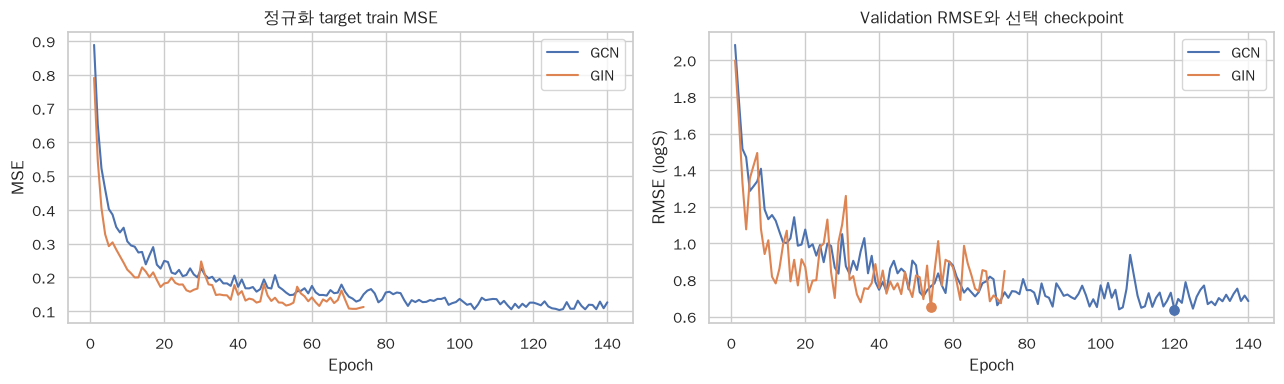

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, result in training_results.items():
    history = pd.DataFrame(result.history)
    axes[0].plot(history["epoch"], history["train_loss"], label=name)
    axes[1].plot(history["epoch"], history["validation_RMSE"], label=name)
    axes[1].scatter(result.best_epoch, result.best_validation_metrics["RMSE"], s=45)
axes[0].set(title="정규화 target train MSE", xlabel="Epoch", ylabel="MSE")
axes[1].set(title="Validation RMSE와 선택 checkpoint", xlabel="Epoch", ylabel="RMSE (logS)")
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

In [8]:
for name, result in training_results.items():
    prediction = predict_gnn(result, dataset, split["validation"], device=DEVICE)
    validation_rows.append({
        "model": name, "representation": "Molecular graph",
        **regression_metrics(targets[split["validation"]], prediction),
    })
validation_metrics = pd.DataFrame(validation_rows).sort_values("RMSE")
display(validation_metrics.round(3))

,model,representation,RMSE,MAE,R2
2,GCN,Molecular graph,0.636,0.495,0.910
3,GIN,Molecular graph,0.652,0.517,0.905
1,MLP,RDKit descriptors,0.837,0.672,0.843
0,Linear Regression,RDKit descriptors,0.973,0.780,0.788


## 5. 고정된 네 모델의 최종 test 비교

이제 validation으로 checkpoint까지 고정했으므로 test를 모델당 정확히 한 번 평가합니다. RMSE와 MAE는 낮을수록, R²는 높을수록 좋습니다.

In [9]:
test_rows = []
test_predictions = {}
for name, model in baseline_models.items():
    prediction = model.predict(X[split["test"]])
    test_predictions[name] = prediction
    test_rows.append({
        "model": name, "representation": "RDKit descriptors",
        **regression_metrics(targets[split["test"]], prediction),
    })
for name, result in training_results.items():
    prediction = predict_gnn(result, dataset, split["test"], device=DEVICE)
    test_predictions[name] = prediction
    test_rows.append({
        "model": name, "representation": "Molecular graph",
        **regression_metrics(targets[split["test"]], prediction),
    })
test_metrics = pd.DataFrame(test_rows).sort_values("RMSE")
display(test_metrics.round(3))

,model,representation,RMSE,MAE,R2
1,MLP,RDKit descriptors,0.730,0.578,0.863
3,GIN,Molecular graph,0.739,0.564,0.860
2,GCN,Molecular graph,0.767,0.603,0.849
0,Linear Regression,RDKit descriptors,0.910,0.738,0.787


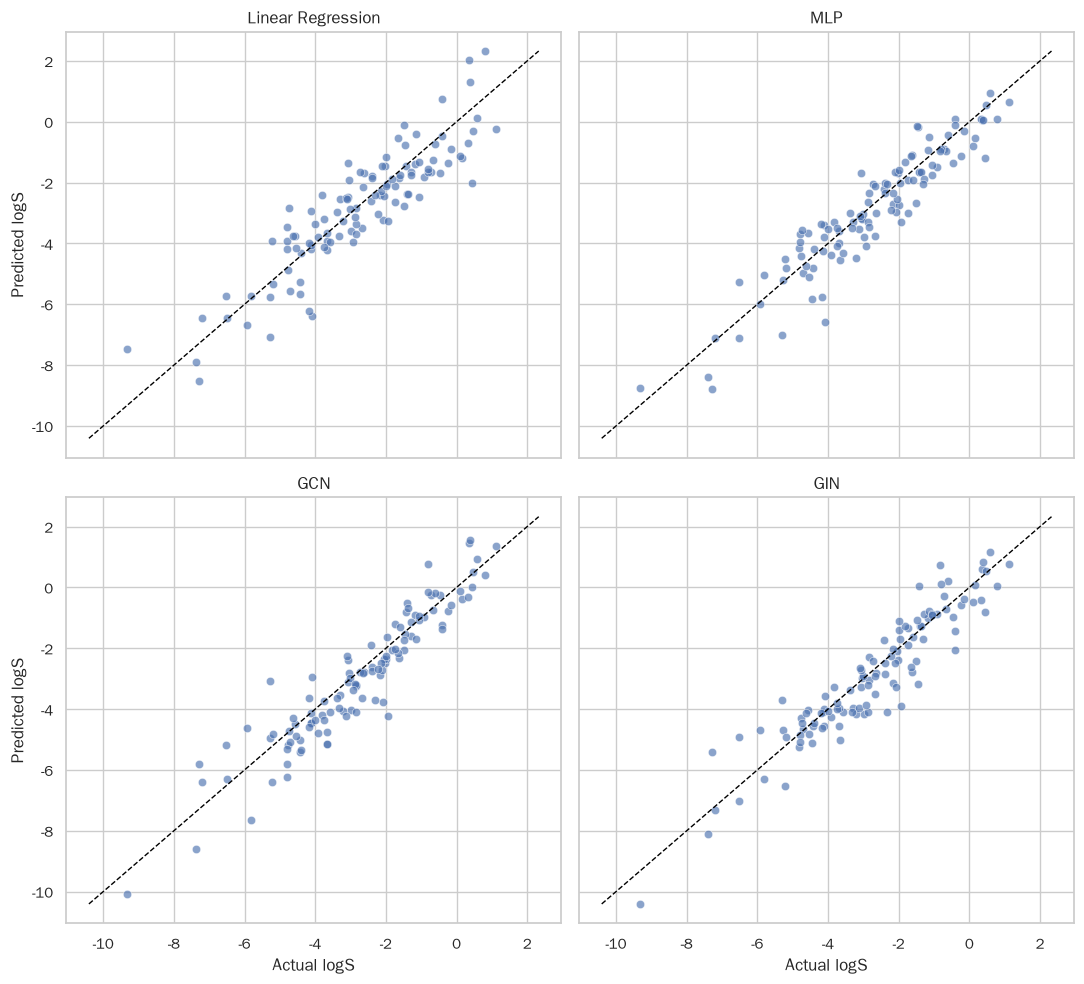

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)
actual = targets[split["test"]]
all_values = np.concatenate([actual, *test_predictions.values()])
limits = (all_values.min(), all_values.max())
for axis, (name, prediction) in zip(axes.flat, test_predictions.items()):
    sns.scatterplot(x=actual, y=prediction, alpha=0.65, ax=axis)
    axis.plot(limits, limits, "--", color="black", linewidth=1)
    axis.set(title=name, xlabel="Actual logS", ylabel="Predicted logS")
plt.tight_layout()
plt.show()

## 6. 결론을 읽는 법

GNN이 Linear보다 좋다면 사람이 정한 다섯 descriptor에 없는 local connectivity 신호를 학습했다는 근거가 됩니다. 하지만 작은 ESOL random split에서는 descriptor MLP가 GNN보다 좋을 수도 있습니다. 그것은 실패가 아니라, **1,128개 표본에서 강한 chemical prior를 가진 descriptor가 data-efficient할 수 있다**는 결과입니다. GIN과 GCN의 차이는 bond 정보를 쓴 효과뿐 아니라 aggregation과 parameter 수의 차이도 함께 포함하므로 단일 run으로 인과 결론을 내리면 안 됩니다. 다음 단계에서는 여러 seed와 scaffold split으로 이 순위가 유지되는지 확인해야 합니다.

In [11]:
best = test_metrics.iloc[0]
best_graph = test_metrics[test_metrics["representation"] == "Molecular graph"].iloc[0]
best_descriptor = test_metrics[test_metrics["representation"] == "RDKit descriptors"].iloc[0]
print(f"최저 test RMSE: {best['model']} ({best['RMSE']:.3f})")
print(f"최고 graph vs descriptor RMSE: {best_graph['RMSE']:.3f} vs {best_descriptor['RMSE']:.3f}")
if best_graph["RMSE"] < best_descriptor["RMSE"]:
    print("이 split에서는 학습한 graph representation이 descriptor baseline을 앞섰습니다.")
else:
    print("이 split에서는 descriptor baseline이 더 data-efficient했습니다. 여러 seed와 scaffold split 확인이 필요합니다.")

최저 test RMSE: MLP (0.730)
최고 graph vs descriptor RMSE: 0.739 vs 0.730
이 split에서는 descriptor baseline이 더 data-efficient했습니다. 여러 seed와 scaffold split 확인이 필요합니다.
